# 02 · Analizar datos reales: de colon al ajuste

**Máster Universitario en Metodología de la Investigación en Ciencias de la Salud**  
Herramientas para el Análisis Bioestadístico: Técnicas Multivariantes y Validez de las Pruebas Diagnósticas  
**Dr. Marcos Lacasa-Cazcarra · Tema 2 · Edición docente 20/09/2026**

Un cuaderno combina **celdas de texto** (explicaciones y respuestas), **celdas de código** (cálculos preparados) y **salidas** (tablas y figuras). No necesitas saber Python.

1. Abre este archivo en [Google Colab](https://colab.research.google.com/) y guarda una copia en tu Drive. Usa una sesión de CPU; no necesitas GPU ni claves.
2. Pulsa ▶ junto a la primera celda de código. Espera al mensaje de bienvenida. Ejecuta después la preparación automática.
3. Sigue el orden. Antes de ejecutar cada bloque, lee y predice. Después escribe tu interpretación mediante doble clic en «Tu respuesta».
4. Puedes ejecutar todas las celdas en orden. Las ampliaciones están al final y se pueden omitir para aprender el recorrido principal.
5. Si algo falla, reinicia la sesión y ejecuta desde el principio. Si persiste, comunica el identificador del bloque; no necesitas reparar el código. Guarda tu copia con las respuestas al acabar.

**Gemini es opcional.** Puedes pedir: «Revisa mi interpretación sin añadir cifras: [mi respuesta]. Señala qué afirmación no está apoyada por esta tabla». Contrasta siempre su respuesta con la salida y el texto. No introduzcas información identificable de pacientes.

Los apartados corresponden a **Tema 2. Análisis de supervivencia**, edición docente 20/09/2026. El enlace local funciona al conservar las carpetas de la entrega. En Colab, abre también el PDF descargado y busca el número de apartado; las prácticas no dependen de que Colab abra enlaces locales.

[PDF de teoría: Tema 2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf)

**Duración de lectura y respuestas estimada:** 120–160 minutos, en tres sesiones. Puedes repartirla en sesiones.

In [1]:
print('Bienvenido/a. La primera celda funciona; continúa con la preparación.')

Bienvenido/a. La primera celda funciona; continúa con la preparación.


### ▶ Preparación automática
Ejecuta y espera a «Entorno preparado». La primera sesión necesita conexión para instalar la herramienta. El código se puede plegar; no lo edites.

In [2]:
NB_ID = 'SurvivalAnalysis02'
BLOQUE = 'preparacion'
PDF_REF = 'Orientacion'
import sys, subprocess, importlib.util, importlib.metadata
if importlib.util.find_spec('lifelines') is None or importlib.metadata.version('lifelines') != '0.30.3':
    print('Preparando las herramientas de supervivencia. Espera a la confirmación...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lifelines==0.30.3'])
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FixedLocator, FuncFormatter, NullFormatter
from pathlib import Path
import json, hashlib, platform, zipfile, io, base64, gzip
from IPython.display import display, Markdown, FileLink
from lifelines import KaplanMeierFitter, NelsonAalenFitter, CoxPHFitter, CoxTimeVaryingFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test, proportional_hazard_test
from lifelines.utils import restricted_mean_survival_time, median_survival_times
import lifelines
from scipy import stats

OUT = Path.cwd() / 'RecursosSupervivencia' / NB_ID
OUT.mkdir(parents=True, exist_ok=True)
RECURSOS = {}
CASOS = {}
CONTEXTO = {}
AZUL, NARANJA, VERDE, MORADO = '#2166AC', '#C65D21', '#16817A', '#8055A5'
COLORES = [AZUL, NARANJA, VERDE, MORADO]
ESTILOS = ['-', '--', '-.', ':']
METODOS = {'01-00': 'Primera sesión: abrir, guardar, ejecutar, responder; Gemini opcional', '01-01': 'Qué estudia la supervivencia: contrato e historias individuales', '01-02': 'Leer S(t)', '01-03': 'Kaplan–Meier: escalones, censuras y pacientes en riesgo', '01-04': 'Supervivencia a un horizonte', '01-05': 'Mediana alcanzada y no alcanzada', '01-06': 'Incertidumbre e IC95 %', '01-07': 'Probabilidad acumulada y complemento', '01-08': 'Hazard: intensidad entre quienes siguen en riesgo', '01-09': 'HR: referencia, dirección, unidad e intervalo', '01-10': 'Mismo HR, distinto riesgo basal y diferencia absoluta', '01-11': '¿Qué pregunta quiero responder? Mapa de decisión, sin desarrollar log-rank ni p-valor', '02-01': 'Contrato del caso real, inclusiones y exclusiones', '02-02': 'Características basales; eventos y seguimiento por separado', '02-03': 'Kaplan–Meier por tratamiento', '02-04': 'S(5), IC y diferencia absoluta', '02-05': 'Log-rank global y comparaciones secundarias con Holm', '02-06': 'Confusión: hospitales con diferente edad', '02-07': 'Cox crudo y ajustado en el mismo ejemplo sintético', '02-08': 'Cox en colon: covariables, referencias y casos completos', '02-09': 'Forest plot: comparación, HR, IC e interpretación', '02-10': 'Proporcionalidad: comparación constante o cambiante', '02-11': 'Schoenfeld: patrón gráfico y contraste', '02-12': 'Forma funcional: recta y spline sin derivación', '02-13': 'Predicción de Cox: perfil, modelo, supuestos y límites para usarla en pacientes', '02-14': 'Informe clínico del caso de colon', '03-01': 'Efecto temporal: comparar horizonte y RMST', '03-02': 'Cambiar el evento: muerte, progresión y PFS', '03-03': 'Recaída con muerte competidora: incidencia acumulada', '03-04': 'Censura: distinguir cantidad y mecanismo', '03-05': 'Entrada tardía: desde cuándo se pertenece al riesgo', '03-06': 'Trasplante, intervalos y tiempo inmortal', '03-07': 'Transferencia a un segundo conjunto Open Data', '03-08': '¿Qué análisis necesito? Hoja del PDF y autoevaluación 03-08 sin cálculo nuevo', '01-A1': 'Apéndice matemático: KM, Greenwood, Cox, log-rank, transformaciones', '01-A2': 'Ampliación clínica: supervivencia condicional', '03-A1': 'Ampliación: censura izquierda y por intervalo', '03-A2': 'Ampliación: corte de calendario, análisis intermedio y multiplicidad', '03-A3': 'Ampliación: error tipo I/II y potencia en simulaciones', '02-A1': 'Ampliación de pronóstico: discriminación, calibración y validación externa'}
mpl.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11, 'axes.titlesize': 15,
    'axes.labelsize': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#8091A5', 'axes.labelcolor': '#20344B',
    'text.color': '#20344B', 'xtick.color': '#40546A', 'ytick.color': '#40546A',
    'axes.grid': True, 'grid.alpha': .18, 'grid.color': '#8091A5',
    'lines.linewidth': 2.2, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'figure.dpi': 110, 'savefig.dpi': 300, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'svg.fonttype': 'none', 'legend.frameon': False,
})

def ptexto(p):
    return 'p < 0,001' if p < .001 else f'p = {p:.3f}'.replace('.', ',')

def contexto(caso, evento, unidad, origen, **extra):
    global CONTEXTO
    CONTEXTO = dict(caso=caso, evento=evento, unidad=unidad, origen=origen, **extra)
    CASOS[caso] = CONTEXTO.copy()

def registrar(ident, archivos, descripcion):
    RECURSOS[ident] = dict(id=ident, bloque=BLOQUE, pdf=PDF_REF, metodo=METODOS.get(BLOQUE),
        convencion_IC='95 % cuando se presenta incertidumbre; intervalos puntuales. Véase pie para resultados sin IC.',
        descripcion=descripcion, contexto=CONTEXTO.copy(),
        archivos=[dict(nombre=p.name, sha256=hashlib.sha256(p.read_bytes()).hexdigest()) for p in archivos])

def figura(fig, ident, descripcion):
    diseno(fig, ident)
    archivos=[]
    for ext in ('pdf', 'svg', 'png'):
        p=OUT/f'{ident}.{ext}'; fig.savefig(p, bbox_inches='tight', facecolor='white'); archivos.append(p)
    registrar(ident, archivos, descripcion)
    plt.show()
    plt.close(fig)
    display(Markdown(f'*Figura {ident}. {descripcion}*'))

def tabla(df, ident, descripcion):
    archivos=[]
    # Conservar números en CSV; evitar que el redondeo presente p = 0,000.
    pcols=[c for c in df.columns if str(c)=='p' or str(c).startswith('p ')]
    presentacion=df.copy()
    fp=lambda x: 'No disponible' if pd.isna(x) else ('< 0,001' if x < .001 else f'{x:.3f}'.replace('.',','))
    for c in pcols: presentacion[c]=df[c].map(fp)
    for ext in ('csv', 'tex', 'html'):
        p=OUT/f'{ident}.{ext}'
        if ext=='csv': df.to_csv(p,index=False,encoding='utf-8',float_format='%.10g')
        elif ext=='tex': p.write_text(presentacion.to_latex(index=False,escape=True,float_format='%.3f'),encoding='utf-8')
        else: p.write_text(presentacion.to_html(index=False,float_format=lambda x:f'{x:.3f}'),encoding='utf-8')
        archivos.append(p)
    registrar(ident, archivos, descripcion)
    display(presentacion.style.format(precision=3,na_rep='No disponible').hide(axis='index'))
    display(Markdown(f'*Tabla {ident}. {descripcion}*'))

def datos(df, ident):
    p=OUT/f'{ident}.csv';df.to_csv(p,index=False,encoding='utf-8',float_format='%.15g')
    registrar(ident,[p],'Datos analíticos de este bloque; véase diccionario en el cuaderno.')
    RECURSOS[ident]['filas']=len(df)
    RECURSOS[ident]['columnas']=list(df.columns)

def curva(ax, km, color=AZUL, estilo='-', ci=True):
    km.plot_survival_function(ax=ax,ci_show=ci,ci_alpha=.13,show_censors=True,
        censor_styles={'marker':'+','ms':5,'mew':1},color=color,ls=estilo)
    ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(-.02,1.03)
    ax.set_ylabel('Probabilidad de seguir sin el evento')

def km_grupos(df, titulo, unidad, orden=None, horizonte=None, ticks=None):
    orden = orden or list(df.grupo.unique())
    max_t = horizonte if horizonte is not None else float(df.tiempo.max())
    ticks = np.linspace(0,max_t,6) if ticks is None else np.array(ticks)
    fig,(ax,ar)=plt.subplots(2,1,figsize=(9,7.5),gridspec_kw={'height_ratios':[4,1.2]})
    ajustes={}
    for j,g in enumerate(orden):
        d=df.loc[df.grupo==g];k=KaplanMeierFitter(label=g).fit(d.tiempo,d.evento);ajustes[g]=k
        curva(ax,k,COLORES[j%4],ESTILOS[j%4]);
        # Recuento justo antes de cada tiempo, sin entrada tardía en esta función.
        for t in ticks: ar.text(t,-j,str(int((d.tiempo>=t).sum())),ha='center',va='center',fontsize=10,color=COLORES[j%4])
    ax.set(title=titulo,xlabel=f'Tiempo ({unidad})',xlim=(0,max_t),xticks=ticks);ax.legend(loc='best',fontsize=10)
    ar.set(xlim=(0,max_t),ylim=(-len(orden)+.3,.75),yticks=-np.arange(len(orden)),yticklabels=orden,xticks=[])
    ar.set_title('Pacientes en riesgo justo antes del tiempo indicado',loc='left',fontsize=10,pad=9)
    for t in ticks: ar.text(t,.42,f'{t:g}',ha='center',fontsize=9,color='#607080')
    ar.grid(False); ar.tick_params(axis='y',length=0,pad=22,labelsize=10)
    for sp in ar.spines.values():sp.set_visible(False)
    fig.tight_layout(pad=2)
    return fig,ajustes

def resumen_km(ajustes, horizonte):
    filas=[]
    for g,k in ajustes.items():
        assert horizonte <= float(np.max(k.durations)), 'Horizonte fuera del seguimiento observado'
        ci=k.confidence_interval_.loc[k.confidence_interval_.index<=horizonte].iloc[-1]
        med=k.median_survival_time_
        filas.append({'Grupo':g,'N':len(k.durations),'Eventos':int(k.event_observed.sum()),
            'Censuras':int(len(k.durations)-k.event_observed.sum()),'Horizonte':horizonte,
            'S(t)':float(k.predict(horizonte)),'IC95 inferior':float(ci.iloc[0]),'IC95 superior':float(ci.iloc[1]),
            'Mediana':f'{med:.2f}' if np.isfinite(med) else 'No alcanzada'})
    return pd.DataFrame(filas)

def forest(modelo, nombres, titulo):
    s=modelo.summary.copy()
    out=pd.DataFrame({'Variable':[nombres.get(x,x) for x in s.index],
        'HR':s['exp(coef)'].values,'IC95 inferior':s['exp(coef) lower 95%'].values,
        'IC95 superior':s['exp(coef) upper 95%'].values,'p':s.p.values})
    fig,ax=plt.subplots(figsize=(9,max(3.5,.58*len(out)+1.8)))
    y=np.arange(len(out));hr=out.HR.to_numpy();lo=out['IC95 inferior'].to_numpy();hi=out['IC95 superior'].to_numpy()
    ax.errorbar(hr,y,xerr=[hr-lo,hi-hr],fmt='o',color=AZUL,ecolor=AZUL,capsize=4,ms=7)
    ax.axvline(1,color='#536678',ls='--',lw=1.4);ax.set_xscale('log')
    xmin,xmax=ax.get_xlim()
    ticks=[x for x in [.125,.25,.5,1,2,4,8,16,32,64] if xmin<=x<=xmax]
    ax.xaxis.set_major_locator(FixedLocator(ticks))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x,pos:f'{x:g}'.replace('.',',')))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set(yticks=y,yticklabels=out.Variable,xlabel='Razón de tasas instantáneas (HR), escala logarítmica',title=titulo)
    ax.invert_yaxis();ax.grid(axis='y',visible=False);fig.tight_layout(pad=2)
    return fig,out

def cerrar():
    meta=dict(cuaderno=NB_ID,version='2026-09-20-reestructuracion',python=platform.python_version(),
        paquetes={k:v for k,v in [('lifelines',lifelines.__version__),('numpy',np.__version__),('pandas',pd.__version__),('matplotlib',mpl.__version__)]},
        casos=CASOS,recursos=list(RECURSOS.values()),estado='Generado por ejecución; revisar informe docente para validación de entrega')
    (OUT/'manifest.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    archivo=OUT.parent/f'{NB_ID}_recursos.zip'
    # Solo archivos registrados: no incluir restos de otras ejecuciones.
    nombres={'manifest.json'}|{f['nombre'] for r in RECURSOS.values() for f in r['archivos']}
    with zipfile.ZipFile(archivo,'w',zipfile.ZIP_DEFLATED) as z:
        for n in sorted(nombres):z.write(OUT/n,arcname=f'{NB_ID}/{n}')
    print(f'Práctica completada: {len(RECURSOS)} recursos preparados. Guarda tu copia con las respuestas.')
    display(FileLink(str(archivo)))
    try:
        from google.colab import files
        import ipywidgets as widgets
        boton=widgets.Button(description='Descargar figuras y tablas',layout=widgets.Layout(width='240px'))
        boton.on_click(lambda _:files.download(str(archivo)))
        display(boton)
    except ImportError:
        print('Los recursos están en la carpeta RecursosSupervivencia de esta sesión.')

print('Entorno preparado. Continúa con el siguiente bloque; no necesitas editar el código.')

Entorno preparado. Continúa con el siguiente bloque; no necesitas editar el código.


In [3]:
def diseno(fig,ident):
    """Tamaño de texto para insertar la figura a160mm en teoría."""
    import textwrap
    from matplotlib.text import Text
    minimo=8.4*fig.get_figwidth()/(160/25.4)
    for item in fig.findobj(match=Text):
        if item.get_visible() and item.get_text():item.set_fontsize(max(item.get_fontsize(),minimo))
    for ax in fig.axes:
        ancho=ax.get_position().width*fig.get_figwidth()
        ancho_texto=30 if ancho<4 else 52
        for loc in ['left','center','right']:
            title=ax.get_title(loc=loc)
            if title:ax.set_title('\n'.join(textwrap.fill(line,width=ancho_texto,break_long_words=False) for line in title.split('\n')),loc=loc,fontsize=max(minimo,14))
    if ident=='02_eventos_censuras':
        fig.axes[0].legend(loc='lower left',bbox_to_anchor=(0,1.03),ncol=2)
        fig.axes[0].set_title('Eventos y censuras durante seguimiento',pad=50)
    if ident=='01_big_agregados':
        fig.axes[0].set_title('A los 5 años\nDiferencia: 2.6 puntos')
        fig.axes[1].set_title('Durante el seguimiento\nHR: 0.81 (IC 95%)')
    if ident=='01_leer_probabilidad':
        for t in fig.axes[1].texts:t.set_position((.5,1.03));t.set_va('bottom')
        fig.axes[1].set_title('Dos probabilidades\ncomplementarias',pad=58)
        fig.axes[1].legend(loc='upper center',bbox_to_anchor=(.5,-.36),ncol=2,fontsize=minimo)
    if ident=='02_schoenfeld':
        for ax in fig.axes:
            ax.legend().remove()
        fig.axes[0].text(.03,.98,'Línea: media por tramo',transform=fig.axes[0].transAxes,va='top',fontsize=minimo)
    fig.tight_layout(pad=1.5)

In [4]:
BLOQUE='preparacion'
PDF_REF='Inicio'

In [5]:
COLON_B64 = '...'
FUENTE = {'url': 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/survival/colon.csv', 'consulta': '2026-09-19', 'sha256': '6f3472a64f696e3195daa198f054180c3e4c66408f7fb8c548c6f4c7b8f898ee', 'documentacion': 'https://stat.ethz.ch/R-manual/R-devel/library/survival/html/colon.html', 'nota': 'Copia pública completa; reemplaza de forma explícita al CSV privado no recuperado.'}

<a id="02-01"></a>
## 02-01 · Colon: personas, registros, desenlaces y diccionario

**Puente al PDF:** [apartado 2.5.1 / 2.5.2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-5-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cuántas personas hay realmente en el archivo?

**Antes de ejecutar.** Dos desenlaces de una persona no son dos personas; selecciona mortalidad antes de contar.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Reutiliza contrato, censura y KM de 01. Aquí el tiempo original está en días y se convierte a años de 365.25 días. «Inicio registrado del seguimiento» no certifica una fecha individual de cirugía. La copia pública histórica puede diferir de muestras y cortes de cada publicación. **No se corrige nodes/node 4 por intuición:** el diccionario reconoce una discrepancia.

In [6]:
BLOQUE='02-01'
PDF_REF='2.5.1 / 2.5.2'
raw=gzip.decompress(base64.b64decode(COLON_B64));assert hashlib.sha256(raw).hexdigest()==FUENTE['sha256']
original=pd.read_csv(io.BytesIO(raw))
colon=original.loc[original.etype.eq(2)].copy()
assert len(original)==1858 and len(colon)==929 and colon.id.is_unique
assert set(colon.status.unique())=={0,1} and (colon.time>0).all()
colon['grupo']=colon.rx.map({'Obs':'Observación','Lev':'Levamisol','Lev+5FU':'Levamisol + 5-FU'})
assert colon.grupo.notna().all()
colon['tiempo']=colon.time/365.25;colon['evento']=colon.status.astype(int)
colon['edad10']=(colon.age-60)/10
orden=['Observación','Levamisol','Levamisol + 5-FU']
contexto('Colon público · mortalidad','Muerte por cualquier causa','años desde el inicio registrado del seguimiento','survival::colon / Rdatasets',
    N=929,fuente=FUENTE,tiempo_original='time en días; conversión /365.25',seleccion='etype=2')
flujo=pd.DataFrame({'Paso':['Registros originales','Identificadores originales','Registros etype=2','Eventos de muerte'],
    'N':[len(original),original.id.nunique(),len(colon),int(colon.evento.sum())]})
tabla(flujo,'02_flujo_poblacion','Dos filas por persona en la fuente; una fila por paciente para mortalidad.')
datos(colon,'02_colon_mortalidad')
dic=pd.DataFrame([
  ['id','Identificador de paciente','Una persona, una fila tras seleccionar etype=2'],
  ['time / tiempo','Seguimiento registrado','Días originales / años de 365,25 días'],
  ['status / evento','Muerte','1 = muerte; 0 = censura'],
  ['rx / grupo','Tratamiento asignado','Obs; Lev; Lev+5FU'],
  ['age / edad10','Edad basal','Años; modelo por 10 años, centrado en 60'],
  ['nodes','Ganglios con afectación','Número; los ausentes se documentan'],
  ['extent','Extensión local','1 submucosa; 2 músculo; 3 serosa; 4 estructuras contiguas'],
  ['etype','Tipo de registro','1 recurrencia; 2 muerte, seleccionado aquí']
],columns=['Variable','Significado','Unidad / codificación'])
tabla(dic,'02_diccionario','Diccionario de las variables usadas; no se adivina el significado de códigos.')

Paso,N
Registros originales,1858
Identificadores originales,929
Registros etype=2,929
Eventos de muerte,452


*Tabla 02_flujo_poblacion. Dos filas por persona en la fuente; una fila por paciente para mortalidad.*

Variable,Significado,Unidad / codificación
id,Identificador de paciente,"Una persona, una fila tras seleccionar etype=2"
time / tiempo,Seguimiento registrado,"Días originales / años de 365,25 días"
status / evento,Muerte,1 = muerte; 0 = censura
rx / grupo,Tratamiento asignado,Obs; Lev; Lev+5FU
age / edad10,Edad basal,"Años; modelo por 10 años, centrado en 60"
nodes,Ganglios con afectación,Número; los ausentes se documentan
extent,Extensión local,1 submucosa; 2 músculo; 3 serosa; 4 estructuras contiguas
etype,Tipo de registro,"1 recurrencia; 2 muerte, seleccionado aquí"


*Tabla 02_diccionario. Diccionario de las variables usadas; no se adivina el significado de códigos.*

### 📖 Paper real · Moertel 1990
[10.1056/NEJM199002083220602](https://pubmed.ncbi.nlm.nih.gov/2300087/)

Ensayo adyuvante de carcinoma de colon resecado. Contexto del ensayo histórico; no se copia una cifra de eficacia al reanálisis.

**Qué mirar:** Referencia NEJM1990;322:352–358. No se importan IC del artículo.

**Pregunta:** ¿Los 929 pacientes de la copia pública son toda la población publicada?

<details><summary>Orientación</summary>

No debe suponerse: muestra, desenlace y seguimiento se documentan en cada fuente.

</details>

*Registro bibliográfico primario indexado, contrastado en EuropePMC. Ejemplo histórico; no recomendación terapéutica actual.*

### 📖 Paper real · Moertel 1995
[10.7326/0003-4819-122-5-199503010-00001](https://pubmed.ncbi.nlm.nih.gov/7847642/)

Informe final del ensayo en estadioIII. Referencia correcta:1995;122:321–326, estadioIII. No copiar año 1991 ni estadioII del diccionario secundario.

**Qué mirar:** Título y ficha bibliográfica. No se importan IC del artículo.

**Pregunta:** ¿Qué versión de seguimiento estoy reanalizando?

<details><summary>Orientación</summary>

La copia pública tiene contrato propio; no asegura reproducir cada tabla del paper.

</details>

*Registro y resumen original. Ejemplo histórico; no recomendación terapéutica actual.*

### 👀 Dónde mirar e interpretar
1858 registros,929 personas tras etype=2;452 muertes. status 0/1 ya es compatible con el análisis.

### 📝 Tu respuesta
¿Por qué no analizar 1858 filas como pacientes?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Duplicaría a cada persona y mezclaría recurrencia con muerte.

</details>

<a id="02-02"></a>
## 02-02 · Características basales; eventos y seguimiento por separado

**Puente al PDF:** [apartado 2.5.3](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-5-3). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué sabemos al inicio y qué observamos después?

**Antes de ejecutar.** Separa características basales de eventos y duración del seguimiento.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

grupo,N,Edad_media,Edad_DE,Ganglios_mediana,Ganglios_ausentes
Observación,315,59.454,11.973,2.000,3
Levamisol,310,60.113,11.645,2.000,6
Levamisol + 5-FU,304,59.701,12.255,2.000,9


*Tabla 02_tabla_basal. Información inicial:edad en años,ganglios en número; DE=desviación estándar.*

grupo,N,Muertes,Censuras
Observación,315,168,147
Levamisol,310,161,149
Levamisol + 5-FU,304,123,181


*Tabla 02_seguimiento. Eventos y censuras observados después del inicio; no son variables basales.*

Mediana de seguimiento (años)
6.439


*Tabla 02_seguimiento_inverso. KM inverso resume observación potencial: no es mediana de supervivencia.*

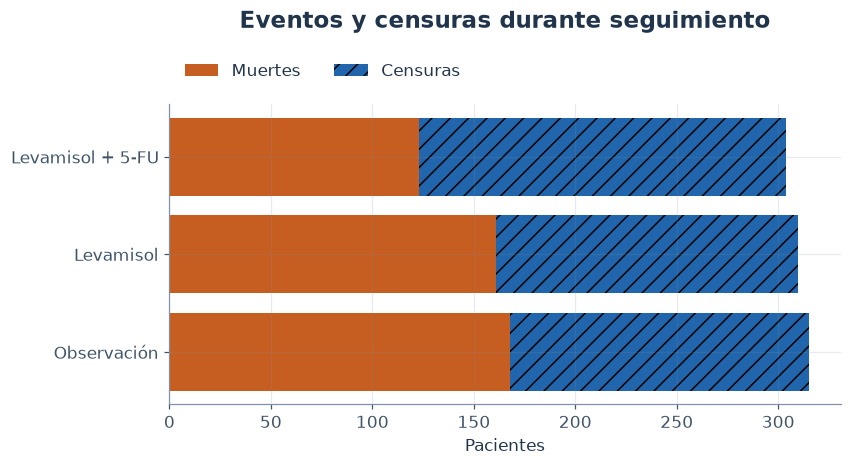

*Figura 02_eventos_censuras. Recuentos, no probabilidades de supervivencia.*

In [7]:
BLOQUE='02-02'
PDF_REF='2.5.3'
basal=colon.groupby('grupo').agg(N=('id','size'),Edad_media=('age','mean'),Edad_DE=('age','std'),Ganglios_mediana=('nodes','median'),Ganglios_ausentes=('nodes',lambda x:x.isna().sum())).reindex(orden).reset_index()
tabla(basal,'02_tabla_basal','Información inicial:edad en años,ganglios en número; DE=desviación estándar.')
seguimiento=colon.groupby('grupo').agg(N=('id','size'),Muertes=('evento','sum')).reindex(orden).reset_index();seguimiento['Censuras']=seguimiento.N-seguimiento.Muertes
tabla(seguimiento,'02_seguimiento','Eventos y censuras observados después del inicio; no son variables basales.')
inversa=KaplanMeierFitter().fit(colon.tiempo,1-colon.evento)
tabla(pd.DataFrame({'Mediana de seguimiento (años)':[inversa.median_survival_time_]}),'02_seguimiento_inverso','KM inverso resume observación potencial: no es mediana de supervivencia.')
basal_eventos=seguimiento.copy()
fig,ax=plt.subplots(figsize=(8,4.5));ax.barh(orden,seguimiento.Muertes,color=NARANJA,label='Muertes');ax.barh(orden,seguimiento.Censuras,left=seguimiento.Muertes,color=AZUL,hatch='//',label='Censuras');ax.set(xlabel='Pacientes',title='Eventos y censuras durante seguimiento');ax.legend();fig.tight_layout();figura(fig,'02_eventos_censuras','Recuentos, no probabilidades de supervivencia.')

> **Apoyo breve:** KM inverso intercambia los papeles de evento y censura para resumir la duración potencial de observación bajo sus supuestos. Se utiliza aquí solo para comunicar seguimiento; no hace falta desarrollar otro método para continuar.

### 👀 Dónde mirar e interpretar
Basal describe inicio; segunda tabla describe seguimiento. La mediana de seguimiento no responde cuánto tarda en morir la mitad.

### 📝 Tu respuesta
Redacta una frase basal y otra de seguimiento.

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Incluye unidades y el nombre de la cantidad; evita llamar supervivencia a 6.44 años de seguimiento.

</details>

<a id="02-03"></a>
## 02-03 · Kaplan–Meier por tratamiento

**Puente al PDF:** [apartado 2.5.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-5-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cómo evolucionan las curvas de los tres tratamientos?

**Antes de ejecutar.** Busca tiempo, evento, cruces e información en riesgo antes de comparar alturas.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

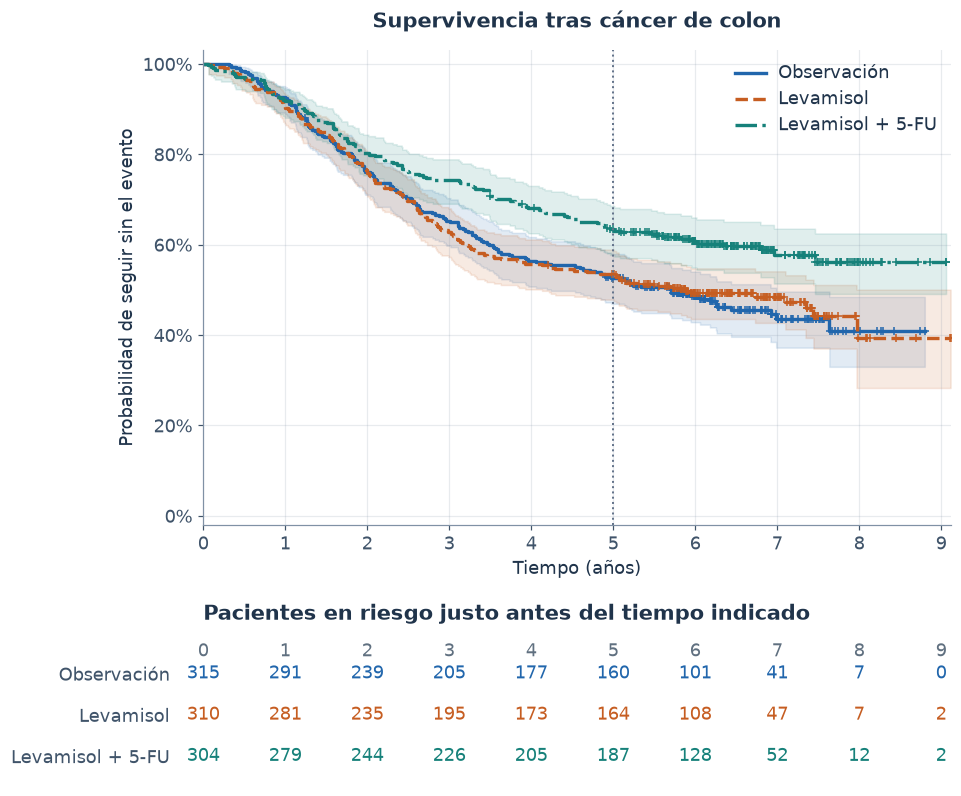

*Figura 02_km_tratamientos. Muerte por cualquier causa; marcas de censura e IC95 % puntual. Datos públicos del ensayo histórico.*

In [8]:
BLOQUE='02-03'
PDF_REF='2.5.4'
fig,kms=km_grupos(colon,'Supervivencia tras cáncer de colon','años',orden=orden,ticks=[0,1,2,3,4,5,6,7,8,9])
fig.axes[0].axvline(5,color='#64748B',ls=':',lw=1.3)
figura(fig,'02_km_tratamientos','Muerte por cualquier causa; marcas de censura e IC95 % puntual. Datos públicos del ensayo histórico.')

### 👀 Dónde mirar e interpretar
Son pacientes de un ensayo histórico. Al final queda menos información.

### 📝 Tu respuesta
¿Por qué una cola separada no basta para concluir gran beneficio?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Faltan número en riesgo, precisión y horizonte prefijado.

</details>

<a id="02-04"></a>
## 02-04 · S(5), IC y diferencia absoluta

**Puente al PDF:** [apartado 2.5.5](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-5-5). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cuánto difiere S(5) entre combinación y observación?

**Antes de ejecutar.** La magnitud se expresa en puntos porcentuales, junto con incertidumbre.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

In [9]:
BLOQUE='02-04'
PDF_REF='2.5.5'
res=resumen_km(kms,5);tabla(res,'02_estimaciones_5a','S(5 años), IC95 % y mediana por tratamiento; valores expresados como probabilidades entre 0 y 1.')
# Bootstrap dentro de cada grupo: diferencia de S(5) entre combinación y observación.
rng=np.random.default_rng(20260919)
def s_en(d,t=5):
    T=d.tiempo.to_numpy();E=d.evento.to_numpy();s=1.
    for u in np.unique(T[(E==1)&(T<=t)]):s*=1-((T==u)&(E==1)).sum()/(T>=u).sum()
    return s
da=colon.loc[colon.grupo.eq(orden[0])];db=colon.loc[colon.grupo.eq(orden[2])]
delta=s_en(db)-s_en(da)
boot=np.array([s_en(db.iloc[rng.integers(0,len(db),len(db))])-s_en(da.iloc[rng.integers(0,len(da),len(da))]) for _ in range(400)])
lo,hi=np.quantile(boot,[.025,.975])
tabla(pd.DataFrame({'Comparación':[f'{orden[2]} menos {orden[0]}'],'Diferencia S(5), puntos %':[100*delta],
    'IC95 bootstrap inferior':[100*lo],'IC95 bootstrap superior':[100*hi]}),'02_diferencia_absoluta','IC percentil con 400 remuestras y semilla fija: ilustración docente de incertidumbre, aproximación no ajustada por multiplicidad.')

Grupo,N,Eventos,Censuras,Horizonte,S(t),IC95 inferior,IC95 superior,Mediana
Observación,315,168,147,5,0.526,0.469,0.579,5.70
Levamisol,310,161,149,5,0.535,0.478,0.589,5.89
Levamisol + 5-FU,304,123,181,5,0.634,0.577,0.685,No alcanzada


*Tabla 02_estimaciones_5a. S(5 años), IC95 % y mediana por tratamiento; valores expresados como probabilidades entre 0 y 1.*

Comparación,"Diferencia S(5), puntos %",IC95 bootstrap inferior,IC95 bootstrap superior
Levamisol + 5-FU menos Observación,10.835,3.593,19.470


*Tabla 02_diferencia_absoluta. IC percentil con 400 remuestras y semilla fija: ilustración docente de incertidumbre, aproximación no ajustada por multiplicidad.*

El IC de la diferencia se aproxima repitiendo el cálculo en remuestras de pacientes dentro de cada grupo. Es una aproximación docente; el procedimiento completo es opcional.

### 👀 Dónde mirar e interpretar
S(5) está entre 0 y 1; la diferencia se multiplica por 100 y se expresa en puntos.

### 📝 Tu respuesta
Redacta diferencia e IC sin llamarlos reducción relativa.

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Aproximadamente 10.8 puntos a favor de combinación, con los límites del IC de la tabla; no convertirlos en HR.

</details>

<a id="02-05"></a>
## 02-05 · Log-rank global y comparaciones secundarias con Holm

**Puente al PDF:** [apartado 2.5.6](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-5-6). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Aporta el seguimiento completo evidencia de diferencias entre curvas?

**Antes de ejecutar.** Mira las mismas curvas de 02-03; ahora la pregunta es global.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Log-rank** compara los eventos observados en los grupos con los esperados según quién seguía en riesgo a lo largo del seguimiento. El resultado global no identifica qué pares difieren ni cuánto. Un p alto no demuestra equivalencia y uno pequeño no mide importancia clínica. Las comparaciones por pares son secundarias; Holm tiene en cuenta que examinamos tres pares. La derivación queda enA.

In [10]:
BLOQUE='02-05'
PDF_REF='2.5.6'
global_lr=multivariate_logrank_test(colon.tiempo,colon.grupo,colon.evento)
tabla(pd.DataFrame({'Contraste':['Global, tres grupos'],'Chi cuadrado':[global_lr.test_statistic],'Grados de libertad':[2],'p':[global_lr.p_value]}),'02_logrank_global','Contraste principal durante todo el seguimiento disponible.')
import itertools
pares=[]
for g,h in itertools.combinations(orden,2):
    a=colon.loc[colon.grupo.eq(g)];d=colon.loc[colon.grupo.eq(h)]
    rr=logrank_test(a.tiempo,d.tiempo,a.evento,d.evento)
    pares.append({'Comparación':g+' vs '+h,'p sin ajustar':rr.p_value})
pares=pd.DataFrame(pares);ix=np.argsort(pares['p sin ajustar'].to_numpy());adjust=np.empty(3)
adjust[ix]=np.minimum(1,np.maximum.accumulate(pares['p sin ajustar'].to_numpy()[ix]*np.array([3,2,1])))
pares['p Holm']=adjust;pares['Lectura']=pares['p Holm'].map(ptexto)
tabla(pares,'02_logrank_pares','Familia de tres contrastes secundarios; Holm controla el error familiar bajo los supuestos de cada contraste.')
print('Contraste global:',ptexto(global_lr.p_value))

Contraste,Chi cuadrado,Grados de libertad,p
"Global, tres grupos",11.683,2,"0,003"


*Tabla 02_logrank_global. Contraste principal durante todo el seguimiento disponible.*

Comparación,p sin ajustar,p Holm,Lectura
Observación vs Levamisol,"0,811","0,811","p = 0,811"
Observación vs Levamisol + 5-FU,"0,002","0,005","p = 0,005"
Levamisol vs Levamisol + 5-FU,"0,004","0,008","p = 0,008"


*Tabla 02_logrank_pares. Familia de tres contrastes secundarios; Holm controla el error familiar bajo los supuestos de cada contraste.*

Contraste global: p = 0,003


### 👀 Dónde mirar e interpretar
Primero contraste global; después pares con p ajustado. Relaciona siempre con S(5) e IC.

### 📝 Tu respuesta
¿Un p alto permitiría escribir «tratamientos equivalentes»?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

No. Equivalencia exige otro planteamiento y márgenes justificados.

</details>

<a id="02-06"></a>
## 02-06 · Confusión: hospitales con diferente edad

**Puente al PDF:** [apartado 2.6.1](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-6-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿El hospital con peor curva necesariamente atiende peor?

**Antes de ejecutar.** Caso sintético distinto: hospitalB tiene pacientes de mayor edad. No reemplaza colon.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Confusión:** la comparación puede mezclar la asociación que interesa con diferencias en los pacientes. En este simulador conocemos que la edad afecta a la muerte y que el hospital no tiene efecto propio.

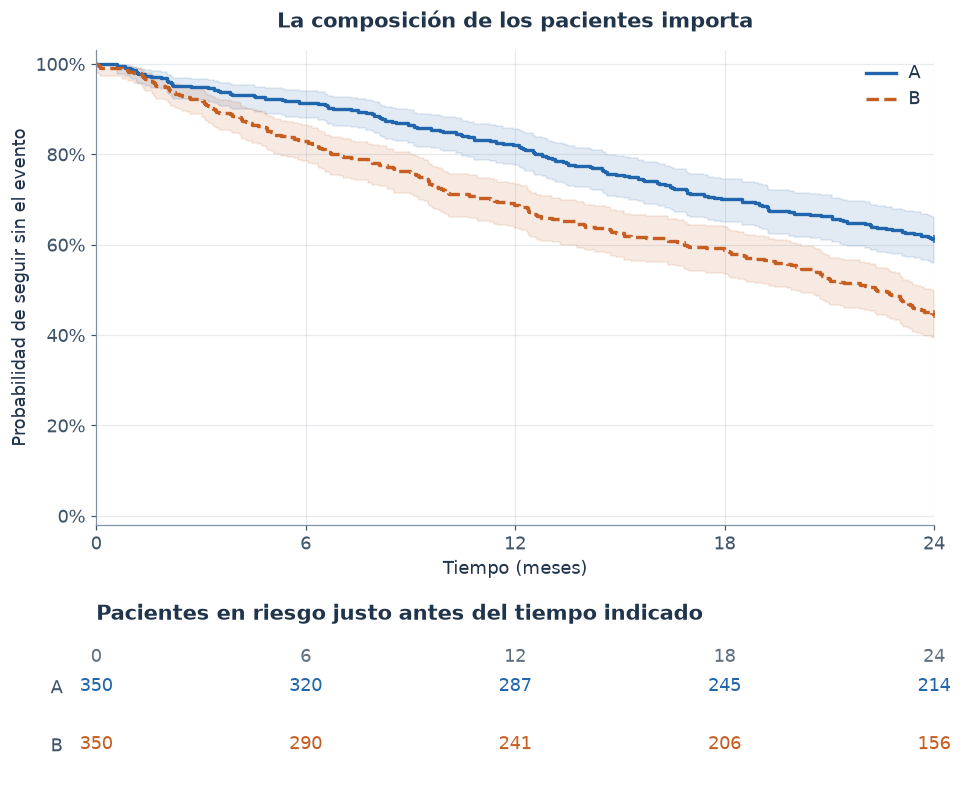

*Figura 03_confusion_hospital. Hospitales ficticios: no hay efecto propio a la misma edad en el mecanismo generador.*

In [11]:
BLOQUE='02-06'
PDF_REF='2.6.1'
contexto('Hospital y edad','Muerte desde ingreso','meses','Simulación con confusión por edad, sin efecto propio de hospital',semilla=2001,N=700)
rng=np.random.default_rng(2001);hospital=np.repeat(['A','B'],350);edad=np.clip(rng.normal(np.where(hospital=='A',52,70),8),25,90)
lat=rng.exponential(1/(.025*np.exp(.035*(edad-60))));ti=np.minimum(lat,24);ev=(lat<=24).astype(int)
h=pd.DataFrame({'tiempo':ti,'evento':ev,'grupo':hospital,'B':(hospital=='B').astype(int),'edad10':(edad-60)/10})
fig,_=km_grupos(h,'La composición de los pacientes importa','meses',ticks=[0,6,12,18,24]);figura(fig,'03_confusion_hospital','Hospitales ficticios: no hay efecto propio a la misma edad en el mecanismo generador.')

In [12]:
BLOQUE='02-06'
PDF_REF='2.6.1'
tabla(h.assign(edad=60+10*h.edad10).groupby('grupo').edad.agg(N='size',Edad_media='mean',Edad_DE='std').reset_index(),'03_edades_hospital','Mismos700 pacientes ficticios; edad en años.')

grupo,N,Edad_media,Edad_DE
A,350,51.011,8.105
B,350,69.685,7.753


*Tabla 03_edades_hospital. Mismos700 pacientes ficticios; edad en años.*

### 👀 Dónde mirar e interpretar
Compara edades antes de atribuir la diferencia al hospital.

### 📝 Tu respuesta
¿Qué explicación alternativa tienen las curvas?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

La composición por edad; conocemos el mecanismo porque lo simulamos.

</details>

<a id="02-07"></a>
## 02-07 · Cox crudo y ajustado en el mismo ejemplo sintético

**Puente al PDF:** [apartado 2.6.2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-6-2). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué cambia al comparar teniendo en cuenta la edad?

**Antes de ejecutar.** Los dos ajustes usan las mismas personas.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Cox** relaciona la tasa del evento con tratamiento o grupo y otras variables del paciente. Estas variables son **covariables**: edad continua, hospital categórico, etc. Ajustar intenta comparar a valores iguales de las covariables incluidas. No elimina sesgos ni demuestra causalidad por sí solo.

In [13]:
BLOQUE='02-07'
PDF_REF='2.6.2'
m0=CoxPHFitter().fit(h[['tiempo','evento','B']],'tiempo','evento');m1=CoxPHFitter().fit(h[['tiempo','evento','B','edad10']],'tiempo','evento')
tabla(pd.DataFrame({'Modelo':['Solo hospital','Hospital y edad'],'HR hospital B/A':[m0.hazard_ratios_['B'],m1.hazard_ratios_['B']],
    'IC95 inferior':[m0.summary.loc['B','exp(coef) lower 95%'],m1.summary.loc['B','exp(coef) lower 95%']],
    'IC95 superior':[m0.summary.loc['B','exp(coef) upper 95%'],m1.summary.loc['B','exp(coef) upper 95%']]}),'03_confusion_ajuste','Comparación en la misma muestra; el generador permite conocer el papel de la edad, algo no garantizado en un estudio real.')
datos(h,'03_datos_hospital')

Modelo,HR hospital B/A,IC95 inferior,IC95 superior
Solo hospital,1.650,1.325,2.054
Hospital y edad,0.878,0.634,1.217


*Tabla 03_confusion_ajuste. Comparación en la misma muestra; el generador permite conocer el papel de la edad, algo no garantizado en un estudio real.*

### 👀 Dónde mirar e interpretar
Compara HR crudo y ajustado e IC, hospitalB respecto aA.

### 📝 Tu respuesta
¿Por qué el HR ajustado no tiene que ser exactamente 1 en esta muestra?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Variación de muestreo; la verdad del generador no obliga al estimador a coincidir exactamente.

</details>

<a id="02-08"></a>
## 02-08 · Cox en colon: covariables, referencias y casos completos

**Puente al PDF:** [apartado 2.6.3](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-6-3). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cómo ajustamos el caso real de colon con un contrato explícito?

**Antes de ejecutar.** Volvemos a colon; edad por 10 años, observación y extensión 1 como referencias.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

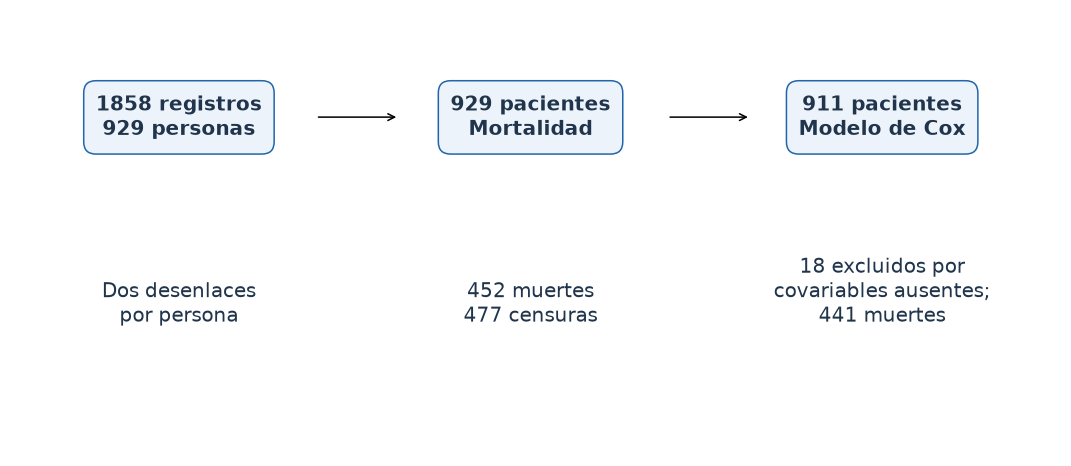

*Figura 02_flujo_pacientes. Se selecciona etype=2 antes de analizar. KM usa 929 pacientes; Cox necesita además las covariables completas y usa 911. No se cuentan filas como personas.*

Paso,Pacientes,Muertes
Mortalidad,929,452
Cox completo,911,441


*Tabla 02_flujo_recuentos. Recuentos verificados del mismo caso.*

In [14]:
BLOQUE='02-08'
PDF_REF='2.6.3'
contexto('Selección del caso de colon','Muerte por cualquier causa','pacientes y registros',
         'Recuentos del mismo CSV público del bloque 02-01')
d=pd.read_csv(OUT/'02_colon_mortalidad.csv')
complete=d[['grupo','edad10','nodes','extent','tiempo','evento']].dropna()
assert len(d)==929 and len(complete)==911
fig,ax=plt.subplots(figsize=(10,4.5));ax.axis('off')
items=[('1858 registros\n929 personas','Dos desenlaces\npor persona'),
       (f'{len(d)} pacientes\nMortalidad',f'{int(d.evento.sum())} muertes\n{int((1-d.evento).sum())} censuras'),
       (f'{len(complete)} pacientes\nModelo de Cox',f'{len(d)-len(complete)} excluidos por\ncovariables ausentes;\n{int(complete.evento.sum())} muertes')]
for j,(title,subtitle) in enumerate(items):
    x=.16+j*.335
    ax.text(x,.72,title,fontsize=13,weight='bold',ha='center',transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=.6',fc='#edf3fa',ec=AZUL))
    ax.text(x,.30,subtitle,fontsize=12,ha='center',transform=ax.transAxes)
    if j<2:ax.annotate('',xy=(x+.21,.76),xytext=(x+.13,.76),xycoords='axes fraction',arrowprops=dict(arrowstyle='->'))
figura(fig,'02_flujo_pacientes','Se selecciona etype=2 antes de analizar. KM usa 929 pacientes; Cox necesita además las covariables completas y usa 911. No se cuentan filas como personas.')
tabla(pd.DataFrame({'Paso':['Mortalidad','Cox completo'],'Pacientes':[len(d),len(complete)],
    'Muertes':[d.evento.sum(),complete.evento.sum()]}),'02_flujo_recuentos','Recuentos verificados del mismo caso.')

In [15]:
BLOQUE='02-08'
PDF_REF='2.6.3'
modelo=colon[['tiempo','evento','grupo','edad10','nodes','extent']].dropna().copy()
formula="C(grupo, Treatment(reference='Observación')) + edad10 + nodes + C(extent)"
cox=CoxPHFitter().fit(modelo,'tiempo','evento',formula=formula)
crudo=CoxPHFitter().fit(modelo,'tiempo','evento',formula="C(grupo, Treatment(reference='Observación'))")
def nombre(x):
    if 'Levamisol + 5-FU' in x:return 'Levamisol + 5-FU vs observación'
    if 'Levamisol' in x:return 'Levamisol vs observación'
    if x=='edad10':return 'Edad: por 10 años más'
    if x=='nodes':return 'Por un ganglio afectado más'
    if 'extent' in x:return 'Extensión '+x.split('T.')[-1].rstrip(']')+' vs 1'
    return x
nombres={x:nombre(x) for x in cox.params_.index}
contexto('Colon público · Cox','Muerte por cualquier causa','años','Casos completos de colon público',
    N=len(modelo),eventos=int(modelo.evento.sum()),excluidos=929-len(modelo),formula=formula,penalizacion=0,fuente=FUENTE)
tabla(pd.DataFrame({'Población':['KM','Cox con covariables completas'],'N':[len(colon),len(modelo)],'Eventos':[int(colon.evento.sum()),int(modelo.evento.sum())]}),'02_muestra_cox','La población del ajuste puede diferir de la usada en las curvas.')
comparacion=pd.DataFrame({'Variable':[nombre(x) for x in crudo.params_.index],
    'HR sin covariables':crudo.hazard_ratios_.values,'HR ajustado':cox.hazard_ratios_.reindex(crudo.params_.index).values})
tabla(comparacion,'02_crudo_ajustado','Ambos modelos usan los mismos pacientes; cambiar el HR al ajustar no demuestra por sí solo confusión ni causalidad.')
datos(modelo,'02_datos_cox')

Población,N,Eventos
KM,929,452
Cox con covariables completas,911,441


*Tabla 02_muestra_cox. La población del ajuste puede diferir de la usada en las curvas.*

Variable,HR sin covariables,HR ajustado
Levamisol vs observación,0.954,0.913
Levamisol + 5-FU vs observación,0.676,0.666


*Tabla 02_crudo_ajustado. Ambos modelos usan los mismos pacientes; cambiar el HR al ajustar no demuestra por sí solo confusión ni causalidad.*

### 👀 Dónde mirar e interpretar
911 casos completos y 441 muertes. Las 18 exclusiones cambian la muestra respecto aKM.

### 📝 Tu respuesta
¿Qué debes comunicar sobre los ausentes?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Número y motivo; casos completos puede introducir sesgo si faltantes están relacionados con pronóstico.

</details>

<a id="02-09"></a>
## 02-09 · Forest plot: comparación, HR, IC e interpretación

**Puente al PDF:** [apartado 2.6.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-6-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cómo traduces una fila del forest a lenguaje clínico?

**Antes de ejecutar.** El punto es HR, el segmento IC y la línea 1 ausencia de asociación en esa escala.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Variable,HR,IC95 inferior,IC95 superior,p
Levamisol vs observación,0.913,0.733,1.137,"0,414"
Levamisol + 5-FU vs observación,0.666,0.526,0.844,"< 0,001"
Edad: por 10 años más,1.059,0.978,1.147,"0,159"
Por un ganglio afectado más,1.094,1.075,1.114,"< 0,001"
Extensión 2 vs 1,2.083,0.640,6.782,"0,223"
Extensión 3 vs 1,3.625,1.161,11.318,"0,027"
Extensión 4 vs 1,5.767,1.749,19.023,"0,004"


*Tabla 02_cox_hr. HR e IC95 % Wald; referencias y unidades en cada etiqueta. No son probabilidades.*

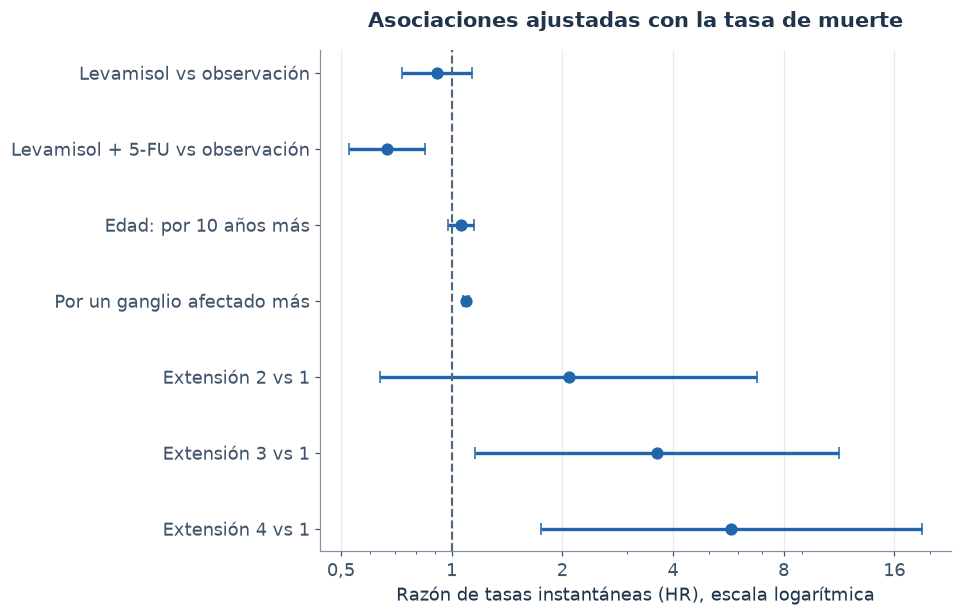

*Figura 02_cox_forest. Línea vertical en HR=1; todos los puntos y extremos están en escala HR. No se confunde con log(HR)=0.*

In [16]:
BLOQUE='02-09'
PDF_REF='2.6.4'
fig,hr=forest(cox,nombres,'Asociaciones ajustadas con la tasa de muerte')
tabla(hr,'02_cox_hr','HR e IC95 % Wald; referencias y unidades en cada etiqueta. No son probabilidades.')
figura(fig,'02_cox_forest','Línea vertical en HR=1; todos los puntos y extremos están en escala HR. No se confunde con log(HR)=0.')

### 👀 Dónde mirar e interpretar
Lee comparación, unidad y referencia antes del punto. Incluir 1 no demuestra igualdad.

### 📝 Tu respuesta
Interpreta combinación frente a observación con su IC.

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Tasa estimada aproximadamente 0.666 veces la referencia, IC 95%0.526–0.844 en este modelo; no es probabilidad individual ni garantía causal.

</details>

<a id="02-10"></a>
## 02-10 · Proporcionalidad: comparación constante o cambiante

**Puente al PDF:** [apartado 2.7.1](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-7-1). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Riesgos proporcionales significa tasas constantes?

**Antes de ejecutar.** Sigue la razón entre tasas, no la altura de cada tasa.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Proporcionalidad:** la razón de tasas entre perfiles se mantiene aproximadamente constante durante el intervalo estudiado. Ambas tasas pueden aumentar. Si cambia la razón, un único HR puede ocultar el patrón temporal.

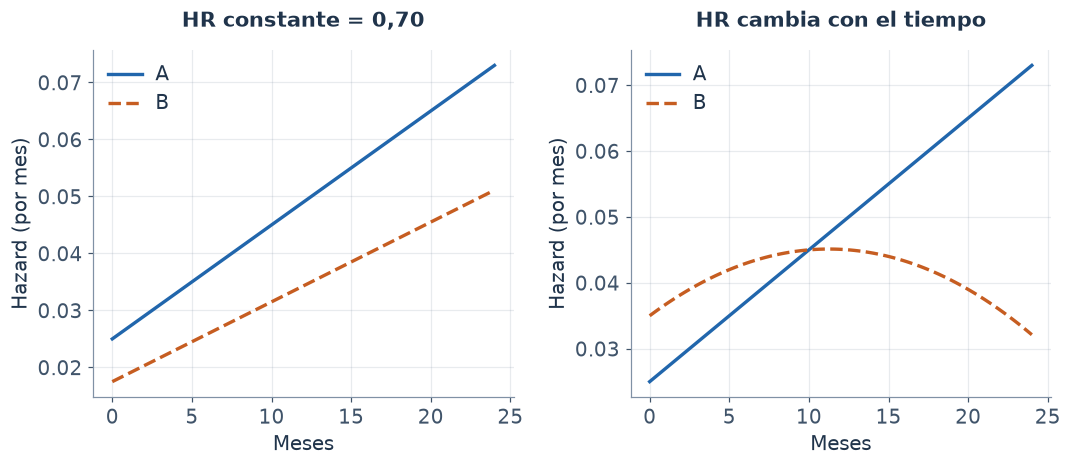

*Figura 02_proporcionalidad_idea. Modelos teóricos: a la izquierda ambas tasas aumentan y su razón permanece constante. Proporcionalidad no exige hazard constante.*

In [17]:
BLOQUE='02-10'
PDF_REF='2.7.1'
contexto('Proporcionalidad','Muerte hipotética','meses','Dos modelos teóricos; no pacientes reales')
t=np.linspace(0,24,100);ha=.025+.002*t
fig,axs=plt.subplots(1,2,figsize=(10,4.5))
for ax,hb,title in [(axs[0],.7*ha,'HR constante = 0,70'),(axs[1],ha*(1.4-.04*t),'HR cambia con el tiempo')]:
    ax.plot(t,ha,label='A',color=AZUL);ax.plot(t,hb,label='B',color=NARANJA,ls='--')
    ax.set(xlabel='Meses',ylabel='Hazard (por mes)',title=title);ax.legend()
fig.tight_layout();figura(fig,'02_proporcionalidad_idea','Modelos teóricos: a la izquierda ambas tasas aumentan y su razón permanece constante. Proporcionalidad no exige hazard constante.')

### 👀 Dónde mirar e interpretar
En el panel izquierdo suben ambas tasas y elHR permanece 0.70.

### 📝 Tu respuesta
¿Qué permanece constante?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

La razón; no cada tasa por separado.

</details>

<a id="02-11"></a>
## 02-11 · Schoenfeld: patrón gráfico y contraste

**Puente al PDF:** [apartado 2.7.2](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-7-2). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Hay señales de que elHR único resume mal colon?

**Antes de ejecutar.** Un residuo contrasta lo observado con lo esperado por el modelo en los eventos.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

Los residuos de **Schoenfeld** ayudan a buscar cambios temporales de una asociación. Se combina patrón gráfico, información disponible y contraste; el p no certifica proporcionalidad. No se seleccionan covariables automáticamente con estas pruebas.

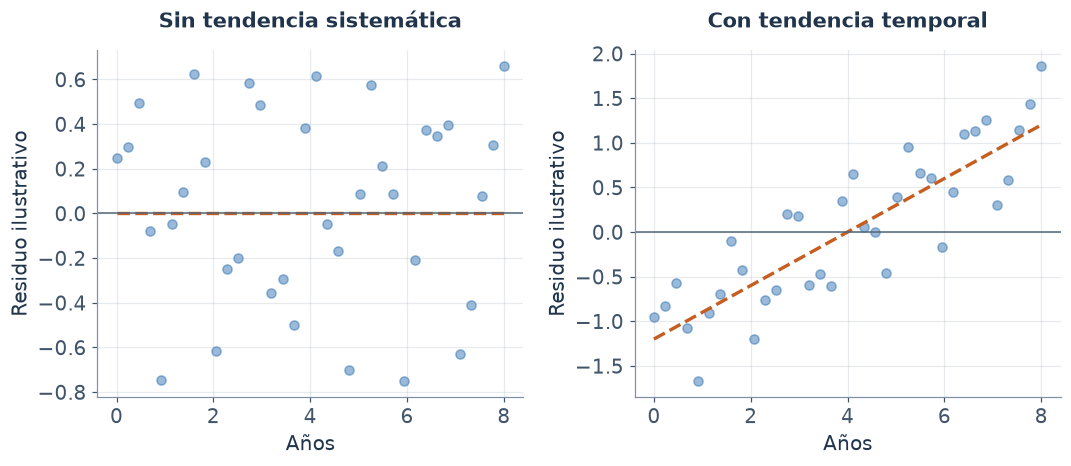

*Figura 02_residuos_idea. Esquemas construidos, sin p-valores: la dirección de un patrón se interpreta con el contraste y la información disponible. No sustituyen los residuos reales del bloque 02-11.*

In [18]:
BLOQUE='02-11'
PDF_REF='2.7.2'
contexto('Patrones de diagnóstico','Muerte hipotética','años','Patrones ilustrativos de residuos; no diagnóstico de colon')
t=np.linspace(0,8,36);noise=.55*np.sin(5*t)+.25*np.cos(11*t)
fig,axs=plt.subplots(1,2,figsize=(10,4.5))
for ax,trend,title in [(axs[0],0*t,'Sin tendencia sistemática'),(axs[1],.3*(t-4),'Con tendencia temporal')]:
    ax.scatter(t,trend+noise,alpha=.45,color=AZUL);ax.plot(t,trend,color=NARANJA,ls='--')
    ax.axhline(0,color='#536678',lw=1);ax.set(title=title,xlabel='Años',ylabel='Residuo ilustrativo')
fig.tight_layout();figura(fig,'02_residuos_idea','Esquemas construidos, sin p-valores: la dirección de un patrón se interpreta con el contraste y la información disponible. No sustituyen los residuos reales del bloque 02-11.')

Variable,Estadístico,p
Extensión 2 vs 1,0.954,"0,329"
Extensión 3 vs 1,0.071,"0,790"
Extensión 4 vs 1,0.006,"0,938"
Levamisol + 5-FU vs observación,1.757,"0,185"
Levamisol vs observación,1.352,"0,245"
Edad: por 10 años más,0.761,"0,383"
Por un ganglio afectado más,0.034,"0,855"


*Tabla 02_proporcionalidad. Contrastes exploratorios de Schoenfeld con transformación por rangos del tiempo; varios diagnósticos, no selección automática de predictores.*

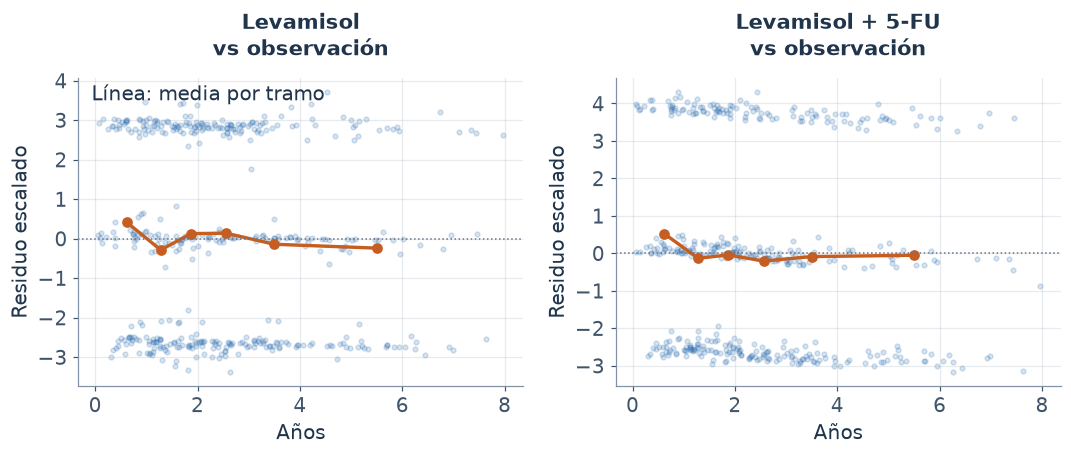

*Figura 02_schoenfeld. Medias descriptivas por tramos, sin banda de confianza. Investigar patrones persistentes; oscilación aleatoria no prueba incumplimiento.*

Diagnósticos con p < 0,05: Ninguno; esto no garantiza proporcionalidad.


In [19]:
BLOQUE='02-11'
PDF_REF='2.7.2'
contexto('Colon público · diagnóstico del Cox','Muerte por cualquier causa','años','Mismos casos completos del ajuste de colon',N=len(modelo),eventos=int(modelo.evento.sum()),fuente=FUENTE)
ph=proportional_hazard_test(cox,modelo,time_transform='rank')
ph_tab=ph.summary.reset_index().rename(columns={'index':'Variable','test_statistic':'Estadístico'})
ph_tab=ph_tab[['Variable','Estadístico','p']]
ph_tab['Variable']=ph_tab.Variable.map(lambda x:nombres.get(x,x))
tabla(ph_tab,'02_proporcionalidad','Contrastes exploratorios de Schoenfeld con transformación por rangos del tiempo; varios diagnósticos, no selección automática de predictores.')
residuos=cox.compute_residuals(modelo,'scaled_schoenfeld')
sel=[x for x in residuos.columns if 'grupo' in x]
fig,axes=plt.subplots(1,len(sel),figsize=(10,4.4),squeeze=False)
for ax,col in zip(axes[0],sel):
    x=modelo.loc[residuos.index,'tiempo'].to_numpy();y=residuos[col].to_numpy()
    ax.scatter(x,y,s=10,alpha=.18,color=AZUL)
    frame=pd.DataFrame({'t':x,'r':y}).sort_values('t');frame['tramo']=pd.qcut(frame.t,6,duplicates='drop')
    medias=frame.groupby('tramo',observed=True)[['t','r']].mean()
    ax.plot(medias.t,medias.r,color=NARANJA,marker='o',label='Media por tramo (descriptiva)')
    ax.axhline(0,color='#657488',ls=':',lw=1);ax.set(title=nombres[col].replace(' vs ','\nvs '),xlabel='Años',ylabel='Residuo escalado');ax.legend(fontsize=8)
fig.tight_layout();figura(fig,'02_schoenfeld','Medias descriptivas por tramos, sin banda de confianza. Investigar patrones persistentes; oscilación aleatoria no prueba incumplimiento.')
print('Diagnósticos con p < 0,05:',', '.join(ph.summary.index[ph.summary.p<.05]) or 'Ninguno; esto no garantiza proporcionalidad.')

### 👀 Dónde mirar e interpretar
El esquema es ilustrativo; después mira los residuos reales y su tabla.

### 📝 Tu respuesta
¿Cómo comunicarías una tendencia persistente?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Que unHR constante puede ser insuficiente; considerar efecto temporal y preguntas alternativas, no ocultar la señal.

</details>

<a id="02-12"></a>
## 02-12 · Forma funcional: recta y spline sin derivación

**Puente al PDF:** [apartado 2.7.3](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-7-3). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cada ganglio adicional tiene el mismo cambio proporcional?

**Antes de ejecutar.** Una forma flexible permite curvatura sin buscar un corte favorable.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

La **forma funcional** describe cómo cambia la asociación al aumentar una variable. Un spline une tramos suaves para permitir curvatura. La comparación es exploratoria; más flexibilidad no garantiza mejor pronóstico.

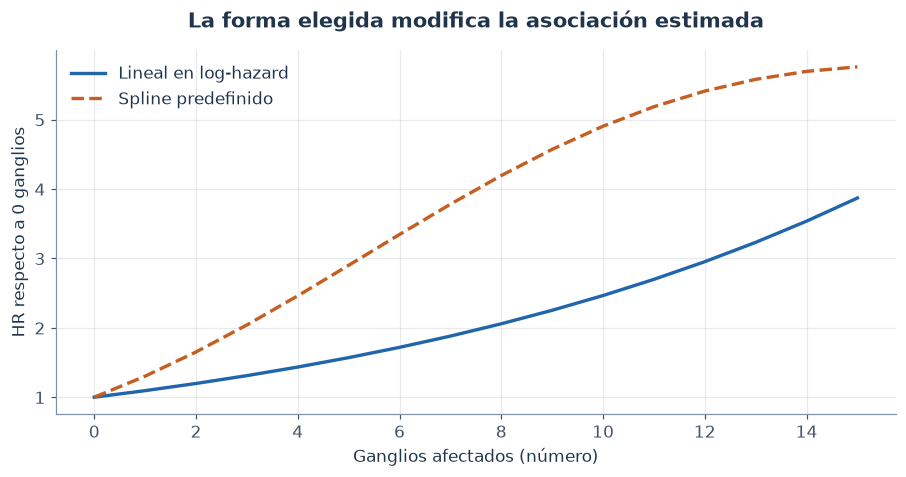

*Figura 02_forma_ganglios. Curvas ajustadas sin intervalos: comparación exploratoria de forma, no validación individual. Se muestra un rango acotado, no extrapolación extrema.*

In [20]:
BLOQUE='02-12'
PDF_REF='2.7.3'
flexible=CoxPHFitter().fit(modelo,'tiempo','evento',formula="C(grupo, Treatment(reference='Observación')) + edad10 + bs(nodes, df=3) + C(extent)")
xx=np.arange(0,16);perfil=pd.DataFrame({'grupo':['Observación']*len(xx),'edad10':[0.]*len(xx),'nodes':xx,'extent':[3]*len(xx)})
ref=pd.DataFrame({'grupo':['Observación'],'edad10':[0.],'nodes':[0],'extent':[3]})
fig,ax=plt.subplots(figsize=(8.5,4.6))
for mod,label,col,ls in [(cox,'Lineal en log-hazard',AZUL,'-'),(flexible,'Spline predefinido',NARANJA,'--')]:
    rr=mod.predict_partial_hazard(perfil).to_numpy()/float(mod.predict_partial_hazard(ref).iloc[0]);ax.plot(xx,rr,label=label,color=col,ls=ls)
ax.set(title='La forma elegida modifica la asociación estimada',xlabel='Ganglios afectados (número)',ylabel='HR respecto a 0 ganglios');ax.legend();fig.tight_layout()
figura(fig,'02_forma_ganglios','Curvas ajustadas sin intervalos: comparación exploratoria de forma, no validación individual. Se muestra un rango acotado, no extrapolación extrema.')

### 👀 Dónde mirar e interpretar
Son curvas ajustadas sinIC; no elegir por apariencia ni afirmar validación.

### 📝 Tu respuesta
¿Qué no puedes concluir de una curva flexible más llamativa?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Que funcione mejor en pacientes nuevos; falta evaluación adicional.

</details>

<a id="02-13"></a>
## 02-13 · Predicción de Cox: perfil, modelo, supuestos y límites para usarla en pacientes

**Puente al PDF:** [apartado 2.7.4](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-7-4). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué significa una predicción de Cox para un perfil?

**Antes de ejecutar.** El perfil fija edad 60 años,2 ganglios y extensión 3; no representa automáticamente a cada grupo.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

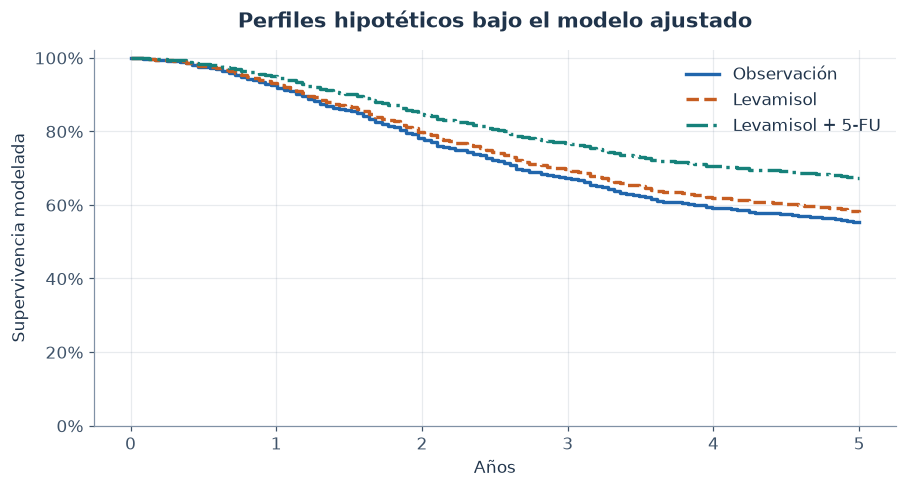

*Figura 02_perfiles_cox. Estimaciones puntuales sin IC; dependen de proporcionalidad y forma funcional. No describen el destino de un paciente concreto.*

Perfil,S modelada a 5 años
Observación,0.552
Levamisol,0.581
Levamisol + 5-FU,0.673


*Tabla 02_prediccion_perfiles. No comparar directamente estas predicciones de perfiles con la media de supervivencia de grupos de composición distinta.*

In [21]:
BLOQUE='02-13'
PDF_REF='2.7.4'
contexto('Colon · perfiles hipotéticos bajo Cox','Muerte por cualquier causa','años','Modelo ajustado en911 casos completos; tres perfiles hipotéticos, no tres pacientes observados',N_ajuste=len(modelo),perfiles=3,edad=60,nodes=2,extent=3,fuente=FUENTE)
perfiles=pd.DataFrame({'grupo':orden,'edad10':[0.,0.,0.],'nodes':[2,2,2],'extent':[3,3,3]})
tiempos=np.linspace(0,5,120);pred=cox.predict_survival_function(perfiles,times=tiempos)
fig,ax=plt.subplots(figsize=(8.5,4.7))
for j,g in enumerate(orden):ax.step(tiempos,pred.iloc[:,j],where='post',label=g,color=COLORES[j],ls=ESTILOS[j])
ax.set(title='Perfiles hipotéticos bajo el modelo ajustado',xlabel='Años',ylabel='Supervivencia modelada',ylim=(0,1.02));ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend();fig.tight_layout()
figura(fig,'02_perfiles_cox','Estimaciones puntuales sin IC; dependen de proporcionalidad y forma funcional. No describen el destino de un paciente concreto.')
tabla(pd.DataFrame({'Perfil':orden,'S modelada a 5 años':pred.iloc[-1].values}),'02_prediccion_perfiles','No comparar directamente estas predicciones de perfiles con la media de supervivencia de grupos de composición distinta.')

### 👀 Dónde mirar e interpretar
Depende del perfil, modelo y supuestos. No es automáticamente una herramienta clínica; requiere evaluación adicional antes de aplicarse a pacientes.

### 📝 Tu respuesta
¿Qué advertencia acompañaría estas cifras?

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Son predicciones condicionadas de un modelo histórico; no una promesa individual ni una herramienta lista para la consulta.

</details>

<a id="02-14"></a>
## 02-14 · Informe clínico del caso de colon

**Puente al PDF:** [apartado 2.7.5](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-2-7-5). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Cómo resumirías el análisis para un colega?

**Antes de ejecutar.** Utiliza resultados anteriores, sin nuevos cálculos.

**Acción.** Escribe tu respuesta usando las salidas anteriores; este bloque no añade cálculos.

### 👀 Dónde mirar e interpretar
Población/evento/horizonte → diferencia eIC → contraste → asociación ajustada → supuestos → límites.

### 📝 Tu respuesta
Escribe un párrafo de 6 frases con cifras de las salidas.

Escribe aquí: …

<details><summary>Orientación: abre después de responder</summary>

Debe distinguir S(5), HR y seguimiento, comunicar exclusiones y evitar afirmar causalidad o equivalencia sin justificación.

</details>

<a id="02-A1"></a>
## 🌱 Opcional · 02-A1 · Ampliación de pronóstico: discriminación, calibración y validación externa

**Puente al PDF:** [apartado B.5](../../Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia/Tema%202%20-%20An%C3%A1 lisis%20 de%20 supervivencia.pdf#nameddest=sec-B-5). En Colab puedes localizarlo por su número.

**Pregunta clínica.** ¿Qué evaluación adicional necesita un modelo pronóstico?

**Antes de ejecutar.** Ampliación opcional; no es una práctica de desarrollo de una herramienta clínica.

**Acción.** Pulsa ▶ en las celdas siguientes. No necesitas cambiar el código.

**Discriminación:** capacidad para ordenar personas según su pronóstico. **Calibración:** concordancia entre probabilidades predichas y observadas a tiempos definidos, considerando censura. **Validación externa:** evaluación en pacientes independientes y pertinentes para el uso previsto. Un buen ajuste en la misma muestra no garantiza ninguna de ellas. Antes de uso clínico también hay que valorar utilidad, consecuencias y población de aplicación.

In [22]:
BLOQUE='02-A1'
PDF_REF='B.5'
contexto('Colon · comparación de formas de Cox','Muerte por cualquier causa','años','Dos especificaciones prefijadas sobre los mismos casos completos',N=len(modelo),fuente=FUENTE)
tabla(pd.DataFrame({'Modelo':['Lineal','Spline, df=3'],'AIC parcial':[cox.AIC_partial_,flexible.AIC_partial_],
    'Parámetros':[len(cox.params_),len(flexible.params_)]}),'02_sensibilidad_forma','AIC equilibra ajuste y complejidad; no debe sustituir evaluación clínica, supuestos ni validación externa.')

Modelo,AIC parcial,Parámetros
Lineal,5601.698,7
"Spline, df=3",5582.553,9


*Tabla 02_sensibilidad_forma. AIC equilibra ajuste y complejidad; no debe sustituir evaluación clínica, supuestos ni validación externa.*

El AIC parcial compara ajuste y complejidad en esta muestra; no mide calibración ni validación externa. No se afirma que aquí se haya validado un modelo clínico.

## ▶ Guardar figuras y tablas
Ejecuta esta última celda. Se preparará un ZIP con PDF/SVG vectoriales, PNG de 300 ppp, tablas CSV/LaTeX/HTML y procedencia. Guarda también tu copia del notebook con las respuestas.

In [23]:
cerrar()

Práctica completada: 31 recursos preparados. Guarda tu copia con las respuestas.


E:\OneDrive\UNIR\TEMAS HERRAMIENTAS AVANZADAS\Revision\reestructuracion_supervivencia_20260920\trabajo\notebooks\RecursosSupervivencia\SurvivalAnalysis02_recursos.zip

Los recursos están en la carpeta RecursosSupervivencia de esta sesión.
